<a href="https://colab.research.google.com/github/OlhaMir/testolha/blob/norma/%D0%9B%D0%A0_2_2_%D0%9C%D1%96%D1%80%D0%BE%D1%88%D0%BD%D0%B8%D0%BA%D0%BE%D0%B2%D0%B0_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

titanic https://www.kaggle.com/datasets/mahmoudshogaa/titanic-dataset?select=titanic.csv

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**Passengerld**: Унікальний ідентифікатор для кожного пасажира.

**Survived**: У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

**Pclass (Клас квитка)**: Показник соціально-економічного статусу, де 1 найвищий клас, а 3 найнижчий.

**Name**: Ім'я пасажира.

**Sex**: Стать пасажира.

**Age**: Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

**SibSp**: Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

**Parch**: Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket**: Номер квитка.

**Fare**: Сума грошей, яку пасажир сплатив за квиток.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
df['Age'] = df['Age'].fillna (df['Age'].median (skipna=True))
df.drop(['Cabin'], axis=1, inplace=True)
df.drop(['Embarked'], axis=1 , inplace=True)

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [10]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_11968/2988914619.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


In [12]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [14]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [15]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


In [16]:
survival_by_sex = df.groupby('Sex') ['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [17]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


In [18]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df [df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df ['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df [df['Pclass'] == 2].shape[0]
class3_surv_rate = df [(df ['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df [df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


In [19]:
survived_mean_age = df [df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df [df['Survived'] == 0] ['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


Різниці в середньому віці особливо немає.

In [21]:
df['Fare_Category'] = pd.qcut(df ['Fare'], 6, labels=False)

for i in range(6):
    surv_rate = df [(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df [df['Fare_Category'] == i].shape[0]
    print(f'Share of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_11968/533816205.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df ['Fare'], 6, labels=False)


Краще виживання у людей з дорожчими білетами.

In [23]:
for i in range(1, 4):
    median_fare = df [df['Pclass'] == i]['Fare'].median()
    print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


<Axes: xlabel='Age', ylabel='Count'>

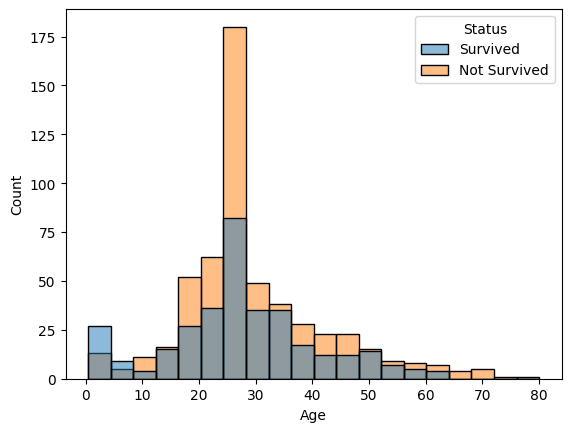

In [24]:
df_survived = df [df ['Survived'] == 1] [['Age']]
df_survived['Status'] = 'Survived'

df_not_survived = df [df['Survived'] == 0] [['Age']]
df_not_survived ['Status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

sns.histplot(data=df_combined, x='Age', hue='Status', bins=20)

In [27]:
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male" if j == 0 else "female"} passengers in class (i): {surv_rate * 100:.2f}%')

Share of survived male passengers in class (i): 36.89%
Share of survived female passengers in class (i): 96.81%
Share of survived male passengers in class (i): 15.74%
Share of survived female passengers in class (i): 92.11%
Share of survived male passengers in class (i): 13.54%
Share of survived female passengers in class (i): 50.00%


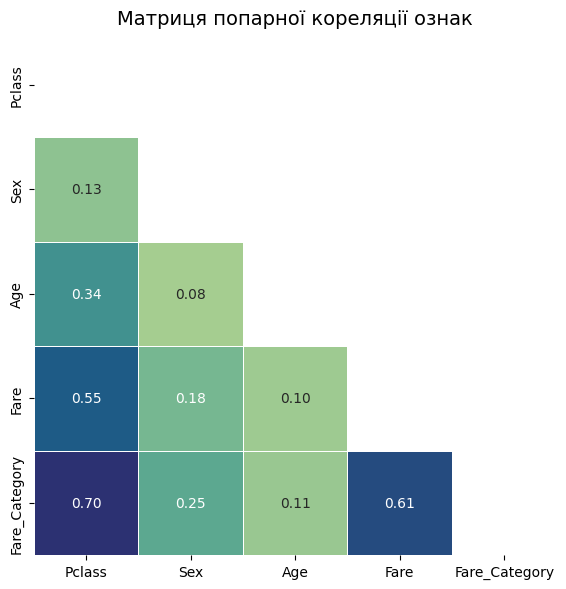

In [29]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots (figsize=(6, 6))
sns.heatmap(
mtx,
cmap='crest',
annot=True,
fmt=".2f",
linewidths=0.5,
mask=np.triu(np.ones_like (mtx, dtype=bool)),
square=True,
cbar=False,
ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

wiki https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C

In [34]:
import requests
from io import StringIO
url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C'

headers = {
"User-Agent": "Mozilla/5.0",
"Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
StringIO(html),
match="Коефіцієнт народжуваності в регіонах України",
thousands=".", decimal=","
)[0]

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Регіон  28 non-null     object 
 1   1950    26 non-null     float64
 2   1960    27 non-null     float64
 3   1970    27 non-null     float64
 4   1990    28 non-null     float64
 5   2000    28 non-null     float64
 6   2012    28 non-null     float64
 7   2014    28 non-null     object 
 8   2019    28 non-null     object 
dtypes: float64(6), object(3)
memory usage: 2.1+ KB


In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.isnull().sum()

,0
Регіон,0
1950,2
1960,1
1970,1
1990,0
2000,0
2012,0
2014,0
2019,0


In [38]:
df = df.replace('—', np.nan)

df = df[df['Регіон'] != 'Україна']

for column in df.columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')

for column in df.columns[1:]:
    df[column] = df[column].fillna(df[column].mean())

In [39]:
df.isnull().sum()

,0
Регіон,0
1950,0
1960,0
1970,0
1990,0
2000,0
2012,0
2014,0
2019,0


In [40]:
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.000,20.600000,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.400,19.200000,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.700,25.000000,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.400,20.400000,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.100,21.400000,14.0,10.9,6.1,9.8,8.200,8.017391
5,Житомирська,26.100,22.300000,15.9,12.9,8.9,12.2,12.000,7.900000
6,Закарпатська,31.400,27.300000,20.7,16.8,11.5,15.1,14.600,10.400000
7,Запорізька,21.900,19.700000,15.0,12.4,7.1,10.6,10.600,6.800000
8,Івано-Франківська,24.300,24.800000,18.2,15.5,10.3,12.4,12.200,8.800000
9,Київська,20.400,18.900000,15.6,12.3,7.3,12.2,12.100,8.000000


In [43]:
df_numeric = df[['Регіон', '1950', '1960', '1970', '1990', '2000', '2012', '2014', '2019']]

df_numeric.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.200,8.017391


In [44]:
print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object


In [45]:
df_numeric.describe()

,1950,1960,1970,1990,2000,2012,2014,2019
count,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000
mean,23.104000,20.757692,15.600000,13.059259,8.222222,11.655556,11.144000,8.017391
std,2.766625,2.935613,1.868772,1.554462,1.584379,1.666718,1.972519,1.364002
min,18.600000,16.300000,12.700000,10.800000,6.100000,9.400000,5.100000,6.000000
25%,21.200000,18.650000,14.400000,12.150000,7.050000,10.300000,10.350000,6.950000
50%,23.000000,20.400000,15.500000,12.600000,7.900000,11.500000,11.144000,8.000000
75%,24.500000,22.050000,16.300000,14.100000,9.000000,12.300000,12.100000,8.750000
max,31.400000,27.300000,20.700000,16.800000,11.800000,15.900000,14.800000,11.000000


In [46]:
df.isnull().sum()

,0
Регіон,0
1950,0
1960,0
1970,0
1990,0
2000,0
2012,0
2014,0
2019,0


In [47]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.144,8.017391
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.900,7.600000
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.100,10.100000
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.100,7.100000
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.200,8.017391


In [48]:
df.tail()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
22,Черкаська,20.500,17.900000,14.4,12.3,7.5,10.0,9.800,6.400000
23,Чернівецька,24.700,21.800000,17.0,14.8,10.1,12.8,12.900,9.200000
24,Чернігівська,22.000,18.300000,12.7,10.8,6.9,9.4,9.000,6.100000
25,Київ,23.104,17.400000,15.9,12.0,7.3,12.0,12.100,11.000000
26,Севастополь,23.104,20.757692,15.6,12.5,7.0,12.0,11.144,8.017391


In [49]:
df_numeric.iloc[:, 1:].mean()

,0
1950,23.104000
1960,20.757692
1970,15.600000
1990,13.059259
2000,8.222222
2012,11.655556
2014,11.144000
2019,8.017391


In [55]:
mean_1950 = df['1950'].mean()
mean_2019 = df['2019'].mean()

change = mean_2019 - mean_1950
change_percent = (change / mean_1950) * 100

print(f'Середнє значення у 1950 році: {mean_1950:.2f}')
print(f'Середнє значення у 2019 році: {mean_2019:.2f}')
print(f'Зміна показника: {change:.2f}')
print(f'Зміна у відсотках: {change_percent:.2f}%')

Середнє значення у 1950 році: 23.10
Середнє значення у 2019 році: 8.02
Зміна показника: -15.09
Зміна у відсотках: -65.30%


In [56]:
for year in ['1950', '1960', '1970', '1990', '2000', '2012', '2014', '2019']:
    max_index = df[year].idxmax()
    min_index = df[year].idxmin()

    print(f'\n{year} рік:')
    print(f'Найвище: {df.loc[max_index, "Регіон"]} — {df.loc[max_index, year]:.2f}')
    print(f'Найнижче: {df.loc[min_index, "Регіон"]} — {df.loc[min_index, year]:.2f}')


1950 рік:
Найвище: Закарпатська — 31.40
Найнижче: Полтавська — 18.60

1960 рік:
Найвище: Закарпатська — 27.30
Найнижче: Полтавська — 16.30

1970 рік:
Найвище: Закарпатська — 20.70
Найнижче: Чернігівська — 12.70

1990 рік:
Найвище: Закарпатська — 16.80
Найнижче: Чернігівська — 10.80

2000 рік:
Найвище: Рівненська — 11.80
Найнижче: Донецька — 6.10

2012 рік:
Найвище: Рівненська — 15.90
Найнижче: Чернігівська — 9.40

2014 рік:
Найвище: Рівненська — 14.80
Найнижче: Луганська — 5.10

2019 рік:
Найвище: Київ — 11.00
Найнижче: Сумська — 6.00


In [57]:
df_numeric['Зміна_%'] = (
    (df_numeric['2019'] - df_numeric['1950']) /
    df_numeric['1950'] * 100
)

df_numeric[['Регіон', 'Зміна_%']]

,Регіон,Зміна_%
0,Крим,-65.141777
1,Вінницька,-66.071429
2,Волинська,-59.109312
3,Дніпропетровська,-65.196078
4,Донецька,-70.415530
5,Житомирська,-69.731801
6,Закарпатська,-66.878981
7,Запорізька,-68.949772
8,Івано-Франківська,-63.786008
9,Київська,-60.784314


In [58]:
df['Category_2019'] = pd.qcut(df['2019'], 3, labels=['Низький', 'Середній', 'Високий'])

print(df[['Регіон', '2019', 'Category_2019']])

               Регіон       2019 Category_2019
0                Крим   8.017391      Середній
1           Вінницька   7.600000      Середній
2           Волинська  10.100000       Високий
3    Дніпропетровська   7.100000       Низький
4            Донецька   8.017391      Середній
5         Житомирська   7.900000      Середній
6        Закарпатська  10.400000       Високий
7          Запорізька   6.800000       Низький
8   Івано-Франківська   8.800000       Високий
9            Київська   8.000000      Середній
10     Кіровоградська   6.800000       Низький
11          Луганська   8.017391      Середній
12          Львівська   8.700000       Високий
13       Миколаївська   7.100000       Низький
14            Одеська   8.800000       Високий
15         Полтавська   6.500000       Низький
16         Рівненська  10.700000       Високий
17            Сумська   6.000000       Низький
18      Тернопільська   7.600000      Середній
19         Харківська   6.800000       Низький
20         Хе

In [59]:
category_mean = df.groupby('Category_2019', observed=True)['1950'].mean()

print(category_mean)

Category_2019
Низький     20.822222
Середній    23.667111
Високий     24.822667
Name: 1950, dtype: float64


In [60]:
print(df['Category_2019'].value_counts())

Category_2019
Низький     9
Середній    9
Високий     9
Name: count, dtype: int64


In [62]:
print(
    df[['Регіон', '1950', '2019', 'Category_2019']]
    .sort_values('2019')
)

               Регіон    1950       2019 Category_2019
17            Сумська  21.600   6.000000       Низький
24       Чернігівська  22.000   6.100000       Низький
22          Черкаська  20.500   6.400000       Низький
15         Полтавська  18.600   6.500000       Низький
19         Харківська  19.700   6.800000       Низький
7          Запорізька  21.900   6.800000       Низький
10     Кіровоградська  21.600   6.800000       Низький
3    Дніпропетровська  20.400   7.100000       Низький
13       Миколаївська  21.100   7.100000       Низький
1           Вінницька  22.400   7.600000      Середній
18      Тернопільська  21.300   7.600000      Середній
21        Хмельницька  23.400   7.900000      Середній
5         Житомирська  26.100   7.900000      Середній
9            Київська  20.400   8.000000      Середній
11          Луганська  26.200   8.017391      Середній
4            Донецька  27.100   8.017391      Середній
26        Севастополь  23.104   8.017391      Середній
0         

Тут вже відсортовано за значеннями.

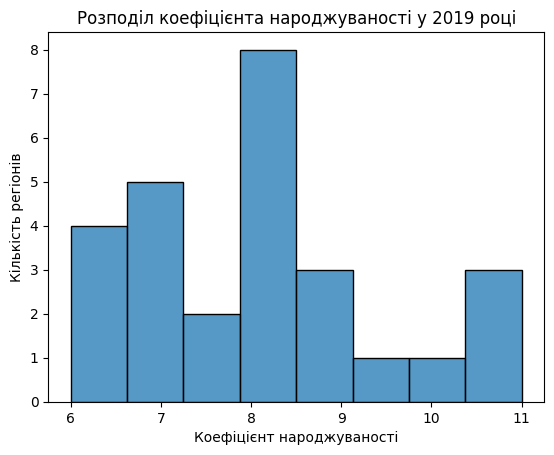

In [64]:
sns.histplot(
    data=df,
    x='2019',
    bins=8
)

plt.title('Розподіл коефіцієнта народжуваності у 2019 році')
plt.xlabel('Коефіцієнт народжуваності')
plt.ylabel('Кількість регіонів')

plt.show()

In [67]:
years = ['1950', '1960', '1970', '1990', '2000', '2012', '2014', '2019']

for year in years:
    mean_value = df[year].mean()
    print(f'Середній коефіцієнт народжуваності у {year} році: {mean_value:.2f}')

Середній коефіцієнт народжуваності у 1950 році: 23.10
Середній коефіцієнт народжуваності у 1960 році: 20.76
Середній коефіцієнт народжуваності у 1970 році: 15.60
Середній коефіцієнт народжуваності у 1990 році: 13.06
Середній коефіцієнт народжуваності у 2000 році: 8.22
Середній коефіцієнт народжуваності у 2012 році: 11.66
Середній коефіцієнт народжуваності у 2014 році: 11.14
Середній коефіцієнт народжуваності у 2019 році: 8.02


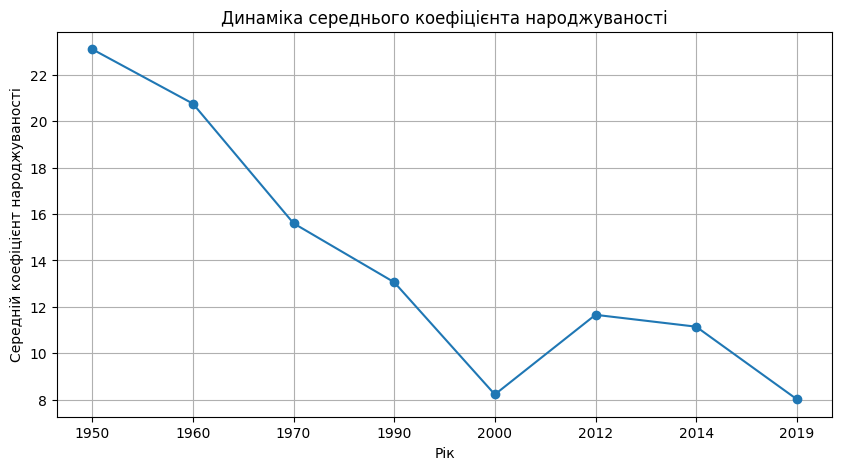

In [65]:
years = ['1950', '1960', '1970', '1990', '2000', '2012', '2014', '2019']

mean_values = df[years].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    years,
    mean_values,
    marker='o'
)

plt.title('Динаміка середнього коефіцієнта народжуваності')
plt.xlabel('Рік')
plt.ylabel('Середній коефіцієнт народжуваності')
plt.grid(True)

plt.show()

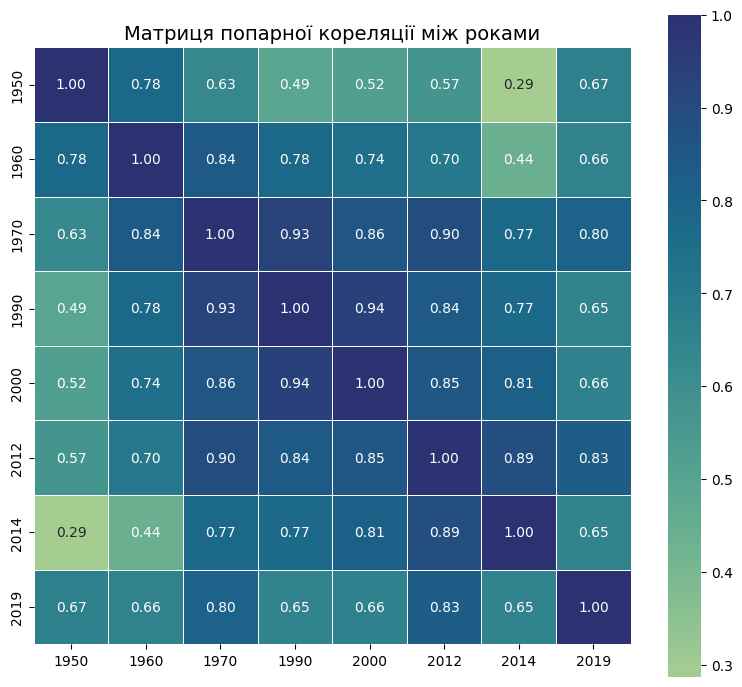

In [66]:
years = ['1950', '1960', '1970', '1990', '2000', '2012', '2014', '2019']

mtx = df[years].corr()

fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar=True,
    ax=ax
)

plt.title('Матриця попарної кореляції між роками', fontsize=14)

plt.tight_layout()
plt.show()

За результатами аналізу таблиці коефіцієнта народжуваності в регіонах України за 1950–2019 роки можна спостерігати загальну тенденцію до зниження показника протягом досліджуваного періоду. Найвищі значення переважно спостерігалися у 1950–1970 роках, тоді як у 2000 та 2019 роках показники були значно нижчими.

Аналіз середніх значень за роками показує поступове зменшення середнього коефіцієнта народжуваності. Особливо помітне зниження спостерігається між 1970 і 2000 роками. У період 2012–2014 років значення дещо підвищуються порівняно з 2000 роком, однак у 2019 році знову спостерігається зниження.

Порівняння регіонів показало, що значення показника відрізнялися залежно від регіону. У різні роки можна спостерігати регіони з максимальними та мінімальними значеннями, що свідчить про територіальні відмінності. Наприклад, у 1950 році високі значення спостерігалися в Закарпатській, Донецькій та Рівненській областях, тоді як нижчі показники були характерні для Полтавської, Харківської та Дніпропетровської областей.

Додаткове групування регіонів за значеннями 2019 року показало, що регіони з високим показником у 2019 році мали в середньому вище значення і в 1950 році. Середнє значення 1950 року для групи з низьким показником у 2019 році становило приблизно 20,82, для середньої групи — 23,67, а для високої — 24,82. Це свідчить про певну схожість відносного розташування регіонів у різні періоди.

Гістограма за 2019 рік показує розподіл регіонів за величиною коефіцієнта народжуваності та дозволяє визначити діапазон, у якому знаходиться більшість спостережень. Лінійний графік середніх значень демонструє загальну довгострокову тенденцію до зниження показника. Матриця кореляції дає змогу побачити взаємозв'язок між значеннями різних років: високі коефіцієнти кореляції між окремими роками свідчать про те, що регіони з відносно вищими або нижчими значеннями зберігали подібне співвідношення між собою протягом певних періодів.

Отже, проведений аналіз показав суттєву зміну коефіцієнта народжуваності в регіонах України протягом 1950–2019 років. Основною тенденцією є довгострокове зниження показника, при цьому між регіонами зберігаються певні відмінності. Використання статистичних характеристик, групування, кореляційного аналізу та графічної візуалізації дозволило комплексно дослідити структуру та динаміку представлених даних.
